 Vehicles Detected: 1
Detected Output View:


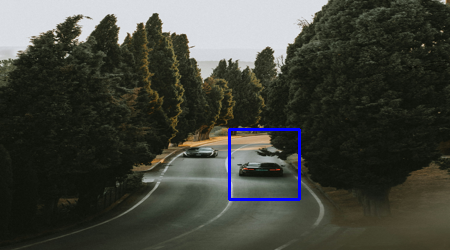

In [1]:
import os
import cv2
import urllib.request
import numpy as np
from PIL import Image

if os.path.exists('sample_data/sample.jpg'):
    image_url = 'sample_data/sample.jpg'
elif os.path.exists('sample.jpg'):
    image_url = 'sample.jpg'
else:
    image_url = 'sample.jpg'


cascade_file = 'cars.xml'
if not os.path.exists(cascade_file):
    print("Downloading Haar Cascade model file...")
    url = "https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml"
    urllib.request.urlretrieve(url, cascade_file)

if os.path.exists(image_url):
    image = Image.open(image_url)
    image = image.resize((450, 250))

    image_arr = np.array(image)

    if image_arr.shape[2] == 4:
        image_arr = cv2.cvtColor(image_arr, cv2.COLOR_RGBA2BGR)
    elif len(image_arr.shape) == 3 and image_arr.shape[2] == 3:
        image_arr = cv2.cvtColor(image_arr, cv2.COLOR_RGB2BGR)

    grey = cv2.cvtColor(image_arr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(grey, (5, 5), 0)
    dilated = cv2.dilate(blur, np.ones((3, 3)))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    closing = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel)

    car_cascade = cv2.CascadeClassifier(cascade_file)
    cars = car_cascade.detectMultiScale(closing, 1.1, 1)

    cnt = 0
    for (x, y, w, h) in cars:
        cv2.rectangle(image_arr, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cnt += 1


    output_image = cv2.cvtColor(image_arr, cv2.COLOR_BGR2RGB)
    annotated_image = Image.fromarray(output_image)

    print(f" Vehicles Detected: {cnt}")
    print("Detected Output View:")
    display(annotated_image)
else:
    print(f" Error: Could not find '{image_url}'. Please upload your file into the Colab files panel.")